In [9]:
%load_ext autoreload
%autoreload 2

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from hubeau.ades import GestionnairePiezometrie

### Téléchargement Piezo

In [11]:
gestionnaire = GestionnairePiezometrie(dossier_sortie="../data")
gestionnaire.telecharger_bassin_versant(['BSS001PGUQ'])


--- Début du traitement pour 1 forages ---
Téléchargement de BSS001PGUQ...
  -> Succès : 13286 mesures sauvegardées dans piezo_BSS001PGUQ.csv
--- Traitement du bassin versant terminé ! ---


In [19]:
df = pd.read_csv('../data/piezo_BSS001PGUQ.csv', sep = ';')
df = df.set_index('date_mesure')
df.head()

,code_bss,bss_id,urn_bss,timestamp_mesure,niveau_nappe_eau,mode_obtention,statut,qualification,code_continuite,nom_continuite,code_producteur,nom_producteur,code_nature_mesure,nom_nature_mesure,profondeur_nappe
date_mesure,,,,,,,,,,,,,,,
1989-01-02,06104X0014/C32,BSS001PGUQ,http://services.ades.eaufrance.fr/pointeau/061...,599745600000,29.13,Valeur mesurée,Donnée contrôlée niveau 2,Correcte,2,Point lié au point précédent,23860001900042,Conseil Régional de Poitou-Charentes (23860001...,N,Naturel,5.48
1989-01-03,06104X0014/C32,BSS001PGUQ,http://services.ades.eaufrance.fr/pointeau/061...,599832000000,29.24,Valeur mesurée,Donnée contrôlée niveau 2,Correcte,2,Point lié au point précédent,23860001900042,Conseil Régional de Poitou-Charentes (23860001...,N,Naturel,5.37
1989-01-04,06104X0014/C32,BSS001PGUQ,http://services.ades.eaufrance.fr/pointeau/061...,599918400000,29.34,Valeur mesurée,Donnée contrôlée niveau 2,Correcte,2,Point lié au point précédent,23860001900042,Conseil Régional de Poitou-Charentes (23860001...,N,Naturel,5.27
1989-01-05,06104X0014/C32,BSS001PGUQ,http://services.ades.eaufrance.fr/pointeau/061...,600004800000,29.45,Valeur mesurée,Donnée contrôlée niveau 2,Correcte,2,Point lié au point précédent,23860001900042,Conseil Régional de Poitou-Charentes (23860001...,N,Naturel,5.16
1989-01-06,06104X0014/C32,BSS001PGUQ,http://services.ades.eaufrance.fr/pointeau/061...,600091200000,29.55,Valeur mesurée,Donnée contrôlée niveau 2,Correcte,2,Point lié au point précédent,23860001900042,Conseil Régional de Poitou-Charentes (23860001...,N,Naturel,5.06


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13286 entries, 1989-01-02 to 2026-05-23
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code_bss            13286 non-null  object 
 1   bss_id              13286 non-null  object 
 2   urn_bss             13286 non-null  object 
 3   timestamp_mesure    13286 non-null  int64  
 4   niveau_nappe_eau    13286 non-null  float64
 5   mode_obtention      13286 non-null  object 
 6   statut              13286 non-null  object 
 7   qualification       13286 non-null  object 
 8   code_continuite     13286 non-null  int64  
 9   nom_continuite      13286 non-null  object 
 10  code_producteur     13286 non-null  int64  
 11  nom_producteur      13286 non-null  object 
 12  code_nature_mesure  13286 non-null  object 
 13  nom_nature_mesure   13286 non-null  object 
 14  profondeur_nappe    13286 non-null  float64
dtypes: float64(2), int64(3), object(10)
memory u

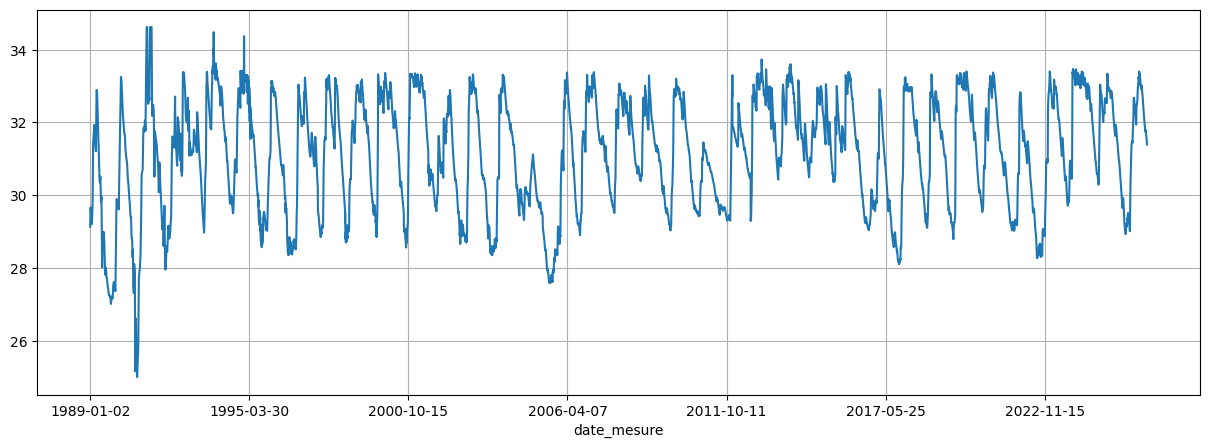

In [23]:

df['niveau_nappe_eau'].plot(kind = 'line', figsize=(15,5))
plt.grid(True)

## Explore Météo

In [53]:
file_climat = '../data/Q_17_previous-1950-2024_RR-T-Vent.csv'

df_climat = pd.read_csv(file_climat, sep = ';')
df_climat['DATE'] = pd.to_datetime(df_climat['AAAAMMJJ'].astype(str), format='%Y%m%d')


#### Localisation et Métadonnées


- NUM_POSTE : Identifiant unique de la station météo (code INSEE + numéro).
- NOM_USUEL : Nom de la commune ou de la station (ex: LA ROCHELLE).
- LAT / LON / ALTI : Latitude, Longitude et Altitude (en mètres) de la station.

🌡️ Températures (en °C)
- TN : Température minimale sous abri.
- TX : Température maximale sous abri.
- TM : Température moyenne.


🌧️ Précipitations
- RR : Hauteur des précipitations (la pluie) du jour, mesurée en millimètres (mm).


💨 Vent (en m/s)
- FFM : Force du vent moyen à 10 mètres de haut.

Les stations n'ont pas de la données sur toutes les mêmes durées. Il y a du tri et du remplissage à faire.

In [54]:
print(df_climat.columns)
df_climat['NUM_POSTE'].unique()

Index(['NUM_POSTE', 'NOM_USUEL', 'LAT', 'LON', 'ALTI', 'AAAAMMJJ', 'RR', 'QRR',
       'TN', 'QTN', 'HTN', 'QHTN', 'TX', 'QTX', 'HTX', 'QHTX', 'TM', 'QTM',
       'TNTXM', 'QTNTXM', 'TAMPLI', 'QTAMPLI', 'TNSOL', 'QTNSOL', 'TN50',
       'QTN50', 'DG', 'QDG', 'FFM', 'QFFM', 'FF2M', 'QFF2M', 'FXY', 'QFXY',
       'DXY', 'QDXY', 'HXY', 'QHXY', 'FXI', 'QFXI', 'DXI', 'QDXI', 'HXI',
       'QHXI', 'FXI2', 'QFXI2', 'DXI2', 'QDXI2', 'HXI2', 'QHXI2', 'FXI3S',
       'QFXI3S', 'DXI3S', 'QDXI3S', 'HXI3S', 'QHXI3S', 'DRR', 'QDRR',
       'STATUS_FXI3S', 'STATUS_DXI3S', 'DATE'],
      dtype='object')


array([17003001, 17004001, 17009001, 17010001, 17016002, 17050001,
       17053001, 17060001, 17068001, 17072001, 17086001, 17093002,
       17111001, 17121001, 17127003, 17132001, 17142001, 17166001,
       17168001, 17172001, 17197001, 17218001, 17224001, 17225001,
       17225002, 17225003, 17226001, 17236001, 17240001, 17241001,
       17243002, 17248001, 17253001, 17266001, 17268002, 17283003,
       17284001, 17299001, 17300001, 17300004, 17300005, 17300006,
       17300009, 17300010, 17300848, 17303001, 17306001, 17306004,
       17308001, 17318001, 17318002, 17323001, 17333001, 17339002,
       17344001, 17347001, 17348001, 17353001, 17369001, 17382001,
       17396001, 17411001, 17411002, 17415003, 17418001, 17421001,
       17434001, 17434002, 17448001, 17451001, 17452001, 17457001,
       17465001, 17469001, 17474001, 17477001])

(7354, 61)

In [60]:
df_climat.groupby(by = 'NUM_POSTE')['DATE'].max().sort_values()

NUM_POSTE
17300010   1950-12-31
17318002   1952-10-31
17300005   1955-02-28
17225002   1956-08-31
17300004   1960-07-31
              ...    
17300009   2024-12-31
17224001   2024-12-31
17268002   2024-12-31
17353001   2024-12-31
17477001   2024-12-31
Name: DATE, Length: 76, dtype: datetime64[ns]

In [ ]:
poste_choisi = 17132001  # Chaban
poste_choisi = 17477001   #
df_poste = df_climat[df_climat['NUM_POSTE'] == poste_choisi]
df_poste.tail()

,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,AAAAMMJJ,RR,QRR,TN,QTN,...,QFXI3S,DXI3S,QDXI3S,HXI3S,QHXI3S,DRR,QDRR,STATUS_FXI3S,STATUS_DXI3S,DATE
820950,17477001,VILLIERS_SAPC,45.9875,-0.152,106,20241227,0.2,1.0,-0.1,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-27
820951,17477001,VILLIERS_SAPC,45.9875,-0.152,106,20241228,0.2,1.0,-0.7,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-28
820952,17477001,VILLIERS_SAPC,45.9875,-0.152,106,20241229,0.0,1.0,0.6,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-29
820953,17477001,VILLIERS_SAPC,45.9875,-0.152,106,20241230,0.0,1.0,3.2,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-30
820954,17477001,VILLIERS_SAPC,45.9875,-0.152,106,20241231,0.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-31


In [62]:
df_poste.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22677 entries, 798278 to 820954
Data columns (total 61 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   NUM_POSTE     22677 non-null  int64         
 1   NOM_USUEL     22677 non-null  object        
 2   LAT           22677 non-null  float64       
 3   LON           22677 non-null  float64       
 4   ALTI          22677 non-null  int64         
 5   AAAAMMJJ      22677 non-null  int64         
 6   RR            22677 non-null  float64       
 7   QRR           22677 non-null  float64       
 8   TN            12051 non-null  float64       
 9   QTN           12051 non-null  float64       
 10  HTN           11946 non-null  float64       
 11  QHTN          11953 non-null  float64       
 12  TX            12049 non-null  float64       
 13  QTX           12049 non-null  float64       
 14  HTX           11980 non-null  float64       
 15  QHTX          11985 non-null  float

<Axes: xlabel='DATE'>

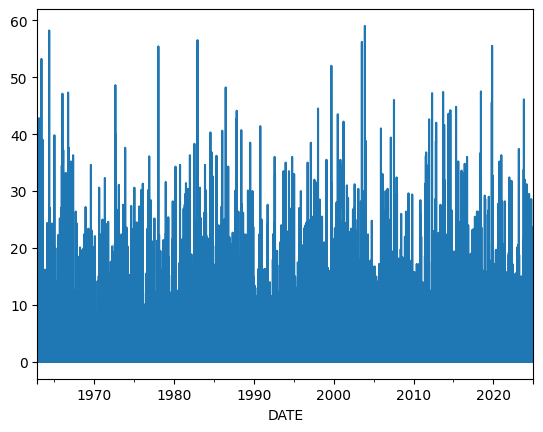

In [66]:
df_poste.set_index('DATE')['RR'].plot(kind = 'line')

1325011   1950-01-01
1325012   1950-01-02
1325013   1950-01-03
1325014   1950-01-04
1325015   1950-01-05
             ...    
1328412   1961-04-26
1328413   1961-04-27
1328414   1961-04-28
1328415   1961-04-29
1328416   1961-04-30
Name: AAAAMMJJ, Length: 3406, dtype: datetime64[ns]